# Detector accuracy against the adjudicated corpora

Scores a detector configuration on the two things per-measurement metrics
cannot express: whether it *finds* events, and how often it fires when nothing
is there. Companion to `analysis-evaluation.ipynb`, which does the same job for
scoring.

Inputs: an event export from the event labeller, an interval export from the
quiet-interval labeller, and ClickHouse on `localhost:9000` with this repo's
tables.

Two things this deliberately does not do.

**It does not replay the incumbent.** The deployed CUSUM is online and its
output depends on the order measurements arrived in, which the pipeline does
not record. Every replay here starts from a cold accumulator, so it scores
stateless candidates exactly and the deployed detector only approximately. That
asymmetry is real, and is itself an argument for making detection stateless.

**It does not score events with no coverage.** An event on networks OONI never
measured cannot be detected by anything, and counting it as a miss makes recall
meaninglessly pessimistic. Rows without `scoreable == "yes"` are excluded and
counted, so the exclusion stays visible.

Read the numbers with their intervals, and read the recall numbers stratified.
The event corpus skews large and famous by construction.

In [6]:
import json
from datetime import datetime, timedelta
from glob import glob

import altair as alt
import numpy as np
import pandas as pd
from clickhouse_driver import Client

# The detector itself is imported, never reimplemented: this notebook exists to
# score the code that runs in production, and a reimplementation would score a
# second detector that happens to resemble it.
from oonipipeline.analysis.detector import detect_changepoints, get_observations

alt.renderers.enable("mimetype")
alt.data_transformers.disable_max_rows()
pd.options.display.max_columns = None

EVENTS_PATH_GLOB = "labels/*event-labels*.json"
INTERVALS_PATH_GLOB = "labels/*interval-labels*.json"

# The configuration under test. DEPLOYED is what `oonipipeline event-detector`
# runs with; the sweep in §7 varies it.
DEPLOYED = dict(edd=10, gap_halflife=48.0)

# How far outside the onset bracket a changepoint still counts as a hit. Reports
# are day-granular, so a tolerance narrower than a day scores the report's
# rounding rather than the detector.
TOLERANCE = timedelta(hours=24)

# Replay lead-in. This is warm-up, not context: a cold CUSUM starts in the `unk`
# state and its first threshold crossing establishes state *silently*, so a
# replay that began at the window edge would swallow the first alert in it.
LEAD = timedelta(days=14)

rng = np.random.default_rng(2026)
client = Client.from_url("clickhouse://localhost:9000/ooni")

## 1. Load the corpora

Only live rows count (`superseded_by` null). Both labellers keep superseded rows
on purpose, and both export them.

`size_band` is derived here rather than read: the schema stores scope, and a
band stored next to it is a second copy that can disagree with the first.

In [2]:
def load(glob_pattern, key):
    """Live rows from every export matching the glob, plus the sampling designs
    they were drawn under (events carry none — they are curated)."""
    rows, designs = [], {}
    for path in sorted(glob(glob_pattern)):
        export = json.load(open(path))
        designs.update(export.get("sampling_designs", {}))
        rows += [r for r in export.get(key, []) if not r.get("superseded_by")]
    return rows, designs


def size_band(e):
    if e.get("asn_scope_kind") == "all":
        return "national"
    if e.get("asn_scope_kind") == "unknown":
        return "unknown"
    if len(e.get("asn_scope") or []) > 1:
        return "multi_asn"
    if e.get("target_set_kind") == "enumerated" and len(e.get("target_set") or []) == 1:
        return "micro"
    return "single_asn"


event_rows, _ = load(EVENTS_PATH_GLOB, "events")
interval_rows, designs = load(INTERVALS_PATH_GLOB, "intervals")

events = pd.DataFrame(event_rows)
if len(events):
    events["size_band"] = [size_band(e) for e in event_rows]

HAVE_INTERVALS = len(interval_rows) > 0
intervals = pd.DataFrame(interval_rows)

print(f"{len(events)} live events, {len(intervals)} live intervals, "
      f"{len(designs)} sampling designs")
if len(events):
    display(events.groupby(["event_class", "scoreable"]).size().unstack(fill_value=0))
if HAVE_INTERVALS:
    display(intervals.groupby(["sampling_stratum", "verdict"]).size().unstack(fill_value=0))
else:
    print("no interval export found — §5 onwards will be skipped")

135 live events, 12 live intervals, 1 sampling designs


scoreable,unknown,yes
event_class,,
true_event,131,4


verdict,event_present,quiet_observed,uncertain
sampling_stratum,,,
detector_alerted,4,2,0
random_covered,0,5,1


## 2. Recompute the interval weights

The stored `sampling_weight` is `population / rows_drawn` at draw time. Two
corrections, the same ones `analysis-evaluation.ipynb` applies to measurement
labels:

- **Replicated draws pool.** Designs sharing a stratum predicate and frame are
  disjoint samples of one population, so their rows pool with
  `weight = population / n_labelled` over the pooled group.
- **The denominator is labelled rows, not drawn rows.** A queue is a
  hash-ordered random permutation, so a partly-worked queue is still a uniform
  sample of its stratum — but the inclusion probability is set by how many rows
  were *judged*, not how many were handed over.

Pooling on the predicate string is what makes the interval partition safe to
rely on here. `random_covered` is defined as the complement of whichever strata
were drawn alongside it, so two designs that partitioned the frame differently
carry different predicates and do not pool — which is correct, because they are
samples of different populations wearing the same stratum name.

Events get no weights, and cannot: they are curated, so there is no frame to
draw from. Event recall below is therefore a coverage statement about a
hand-built set, not an estimate of anything.

In [3]:
def stratum_groups(designs):
    groups = {}
    for did, d in designs.items():
        for name, s in d["strata"].items():
            key = (s["predicate"], s["frame_start"], s["frame_end"])
            g = groups.setdefault(key, {"stratum": name, "populations": [], "members": set()})
            g["populations"].append(s["population_estimate"])
            g["members"].add((did, name))
    return groups


if HAVE_INTERVALS:
    groups = stratum_groups(designs)
    member_to_key = {m: key for key, g in groups.items() for m in g["members"]}

    intervals["group_key"] = [
        member_to_key[(r.sampling_design_id, r.sampling_stratum)]
        for r in intervals.itertuples()
    ]
    n_labelled = intervals.groupby("group_key").size()

    weights = pd.DataFrame([
        {
            "group_key": key,
            "stratum": g["stratum"],
            "population": float(np.mean(g["populations"])),
            "designs": len(g["members"]),
            "n_labelled": int(n_labelled.get(key, 0)),
            "weight": (float(np.mean(g["populations"])) / int(n_labelled.get(key, 0))
                       if n_labelled.get(key, 0) else np.nan),
        }
        for key, g in groups.items()
    ]).set_index("group_key")

    intervals["w"] = intervals.group_key.map(weights.weight)
    display(weights[["stratum", "population", "designs", "n_labelled", "weight"]])

,stratum,population,designs,n_labelled,weight
group_key,,,,,
"(concat(probe_cc, '|', toString(probe_asn), '|', domain, '|', toString(week)) IN (\n SELECT concat(probe_cc, '|', toString(probe_asn), '|', domain, '|', toString(toStartOfWeek(ts, 1)))\n FROM event_detector_changepoints\n WHERE ts >= %(since)s AND ts < %(until)s AND change_dir > 0\n), 2026-05-18T00:00:00, 2026-08-03T00:00:00)",detector_alerted,1414.0,1,6,235.666667
"(NOT (concat(probe_cc, '|', toString(probe_asn), '|', domain, '|', toString(week)) IN (\n SELECT concat(probe_cc, '|', toString(probe_asn), '|', domain, '|', toString(toStartOfWeek(ts, 1)))\n FROM event_detector_changepoints\n WHERE ts >= %(since)s AND ts < %(until)s AND change_dir > 0\n)), 2026-05-18T00:00:00, 2026-08-03T00:00:00)",random_covered,265132.0,1,6,44188.666667


## 3. Replay

One fetch per corpus row, then as many replays as we like over the observations
in memory. The sweep in §7 re-scores every event and every interval at a dozen
parameter settings; re-querying for each would make that a database exercise
rather than an analysis, and the observations do not change between settings.

`detect_changepoints` groups by `(probe_cc, probe_asn, domain)` with
`itertools.groupby`, so the input has to be sorted that way — an unsorted list
silently produces a separate cold-started detector per run of rows.

In [4]:
_obs_cache = {}


def observations(probe_cc, domains, start, end, asns=None):
    """Hourly cell observations for a scope, cached across replays."""
    key = (probe_cc, tuple(sorted(domains)), start, end, tuple(sorted(asns)) if asns else None)
    if key in _obs_cache:
        return _obs_cache[key]
    obs = list(get_observations(
        client, start_time=start, end_time=end,
        domains=list(domains), probe_cc=[probe_cc] if probe_cc else None,
    ))
    if asns:
        obs = [o for o in obs if o["probe_asn"] in asns]
    obs.sort(key=lambda o: (o["probe_cc"], o["probe_asn"], o["domain"], o["ts"]))
    _obs_cache[key] = obs
    return obs


def naive(dt):
    """The analysis columns are DateTime64(_, 'UTC') so ClickHouse hands back
    aware datetimes, while label timestamps are naive UTC strings. Everything
    is UTC; comparing the two forms is what breaks."""
    return dt.replace(tzinfo=None) if dt.tzinfo else dt


def replay(obs, **params):
    """Cold-start replay. Returns positive changepoints, as (ts, row)."""
    if not obs:
        return []
    cps, _, _ = detect_changepoints(obs, {}, **params)
    return [(naive(c["ts"]), c) for c in cps if c["change_dir"] > 0]


def parse(ts):
    if not ts:
        return None
    return datetime.fromisoformat(str(ts).replace("Z", "").split("+")[0])

## 4. Event recall, latency and alert flood

Three questions per event. Did a positive changepoint land inside the onset
bracket widened by the tolerance — that is a hit, and its offset from
`onset_earliest` is the latency. How many fired in total inside the event — that
is the alert flood, and forty alerts for one event is a paging problem even at
perfect recall. And for `false_positive_event` rows the test inverts: any
changepoint at all is a failure, which makes an adjudicated false alarm a
must-not-fire regression.

Latency can be negative. Reports are day-granular and usually lag the block, so
firing before the bracket opens is a good outcome, not a sign error.

In [7]:
def score_event(e, **params):
    """None when the event cannot be scored at all — no enumerated targets, no
    bracket, or no measurements in scope."""
    targets = e.get("target_set") or []
    if e.get("target_set_kind") != "enumerated" or not targets:
        return None
    onset_lo = parse(e.get("onset_earliest"))
    if onset_lo is None:
        return None
    onset_hi = parse(e.get("onset_latest")) or onset_lo
    resolved = parse(e.get("resolution_latest"))

    asns = set(e.get("asn_scope") or []) if e.get("asn_scope_kind") == "listed" else None
    obs = observations(
        e.get("probe_cc"), targets,
        onset_lo - LEAD, (resolved or onset_hi) + TOLERANCE, asns=asns,
    )
    if not obs:
        return None

    onsets = replay(obs, **params)
    lo, hi = onset_lo - TOLERANCE, onset_hi + TOLERANCE
    in_bracket = [t for t, _ in onsets if lo <= t <= hi]
    in_window = [t for t, _ in onsets if lo <= t <= (resolved or hi)]

    return {
        "event_id": e["event_id"],
        "title": e.get("title") or e["event_id"],
        "probe_cc": e.get("probe_cc") or "",
        "size_band": size_band(e),
        "event_class": e.get("event_class") or "true_event",
        "detected": bool(in_bracket),
        "latency_hours": ((min(in_bracket) - onset_lo).total_seconds() / 3600.0
                          if in_bracket else np.nan),
        "alerts_in_window": len(in_window),
        "series": len({(o["probe_cc"], o["probe_asn"], o["domain"]) for o in obs}),
    }


def score_events(rows, **params):
    scored, excluded = [], {}
    for e in rows:
        if e.get("scoreable") != "yes":
            reason = e.get("scoreable") or "unknown"
        elif not (e.get("mechanisms") or []):
            # An event with no mechanism has not been adjudicated, only imported.
            reason = "no_mechanism"
        else:
            r = score_event(e, **params)
            if r is not None:
                scored.append(r)
                continue
            reason = "no_series"
        excluded[reason] = excluded.get(reason, 0) + 1
    return pd.DataFrame(scored), excluded


ev, ev_excluded = score_events(event_rows, **DEPLOYED)
true_events = ev[ev.event_class == "true_event"] if len(ev) else ev
print(f"scored {len(ev)} events, excluded {sum(ev_excluded.values())} {ev_excluded}")
if len(true_events):
    print(f"recall                          {true_events.detected.mean():.0%}")
    print(f"median detection latency        {true_events.latency_hours.median():.1f}h")
    hit = true_events[true_events.detected]
    print(f"alerts per detected true event  {hit.alerts_in_window.mean():.1f}")
    display(true_events.groupby("size_band").detected.agg(["sum", "size", "mean"]))

scored 4 events, excluded 131 {'unknown': 131}
recall                          75%
median detection latency        17.0h
alerts per detected true event  2.3


,sum,size,mean
size_band,,,
micro,1,1,1.0
multi_asn,1,2,0.5
single_asn,1,1,1.0


Unstratified recall is the optimistic number, which is why the band breakdown
sits next to it. A national, multi-target, well-measured event is a step
function a threshold detector cannot miss; a single-ASN block of one domain in a
country with four probes is the case that decides whether this detector is
useful, and it is also the case the corpus has fewest of.

The failures below are the working list. A miss on a `true_event` and a fire on
a `false_positive_event` are different bugs, so they are named separately.

In [8]:
if len(ev):
    failed = ev[
        ((ev.event_class == "true_event") & ~ev.detected)
        | ((ev.event_class == "false_positive_event") & (ev.alerts_in_window > 0))
    ].copy()
    failed["failure"] = np.where(
        failed.event_class == "false_positive_event", "fired when it should not", "missed"
    )
    display(failed[["probe_cc", "title", "size_band", "failure", "series"]]
            .sort_values(["failure", "probe_cc"]))

,probe_cc,title,size_band,failure,series
0,RU,Russia blocked Bluesky,multi_asn,missed,8


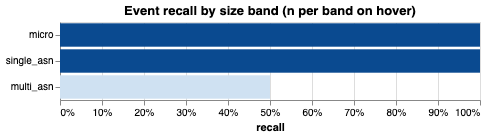

In [9]:
if len(true_events):
    band_order = ["micro", "single_asn", "multi_asn", "national", "unknown"]
    by_band = (true_events.groupby("size_band")
               .agg(recall=("detected", "mean"), n=("detected", "size"))
               .reindex([b for b in band_order if b in set(true_events.size_band)])
               .reset_index())
    display(
        alt.Chart(by_band).mark_bar().encode(
            x=alt.X("recall:Q", scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(format="%")),
            y=alt.Y("size_band:N", sort=band_order, title=None),
            color=alt.Color("recall:Q", scale=alt.Scale(scheme="blues"), legend=None),
            tooltip=["size_band", alt.Tooltip("recall", format=".0%"), "n"],
        ).properties(width=420, height=26 * len(by_band),
                     title="Event recall by size band (n per band on hover)")
    )

## 5. The false-alarm rate, over sampled silent time

Recall says whether a change still finds what it should. It says nothing about
what the change costs, and the event corpus cannot: it is curated, so there is
no denominator in it. Counting alarms in the lead-in of known events — which is
what the old CLI harness did — measures quiet time over "whatever cells happen
to surround an adjudicated event", a population nothing sampled and one
concentrated in exactly the countries and networks where quiet time is least
typical.

The interval corpus is a draw from a frame, so the rate is estimable. Each row
is weighted by `population / n_labelled` for its stratum
([Horvitz-Thompson](https://en.wikipedia.org/wiki/Horvitz%E2%80%93Thompson_estimator)),
because the queue oversamples alerted and near-miss weeks on purpose: a uniform
draw is almost all trivially quiet cells and costs analyst time to learn
nothing. Unweighted, the number would describe the queue.

**The denominator is silence, not calm.** A changepoint detector can only be
right or wrong about a *transition*, so both `quiet_observed` and
`blocked_throughout` weeks belong in it: neither contains one, the detector
should fire in neither, and an alert in either is a false alarm. They are
reported together and split, because they fail differently — an alert in a
quiet week is noise, an alert inside an ongoing block is a duplicate page on
something already known. Dropping `blocked_throughout` from the denominator
instead (which is what labelling those weeks `event_present` amounts to) lets a
detector that re-fires all through a long block score clean on recall *and* on
false alarms.

The verdict is `quiet_observed`, never `quiet`. The week was judged from the
same OONI data the detector reads, so an unmeasured block is indistinguishable
from calm and this is an upper bound on quality rather than a certificate.
Contamination of that kind biases the rate *upward*, which is the safe
direction.

In [ ]:
# Weeks with no transition in them, whatever the level: the detector should be
# silent in all of these, so they are what a false-alarm rate is a rate over.
SILENT = ("quiet_observed", "blocked_throughout")
SCORED = SILENT + ("event_present",)


def score_interval(row, **params):
    start, end = parse(row["window_start"]), parse(row["window_end"])
    obs = observations(row["probe_cc"], [row["domain"]], start - LEAD, end,
                       asns={int(row["probe_asn"])})
    if not obs:
        return None
    alerts = sum(1 for t, _ in replay(obs, **params) if start <= t < end)
    return {
        "probe_cc": row["probe_cc"],
        "probe_asn": int(row["probe_asn"]),
        "domain": row["domain"],
        "window_start": start,
        "verdict": row["verdict"],
        "stratum": row["sampling_stratum"],
        "group_key": row["group_key"],
        "w": row["w"],
        # Derived from the count, not read off the row: a merged or hand-edited
        # corpus can carry a band that disagrees with its own measurement count.
        "volume_band": ("low" if row["measurements_in_window"] < 100
                        else "medium" if row["measurements_in_window"] < 1000 else "high"),
        "measurements": int(row["measurements_in_window"]),
        "alerts": alerts,
        "cluster": (row["probe_cc"], start.strftime("%G-W%V")),
    }


def score_intervals(frame, **params):
    scored, excluded = [], {}
    for row in frame.to_dict("records"):
        if row["verdict"] not in SCORED:
            # `uncertain` and `unusable` are counted, not dropped. A corpus that
            # quietly loses its ambiguous rows keeps only the easy negatives,
            # and the rate improves for a reason that appears in no number here.
            reason = row["verdict"]
        elif not row.get("w") or np.isnan(row["w"]):
            # The one field that cannot be recovered after the fact, so a row
            # missing it is not repairable by being generous about it.
            reason = "no_weight"
        else:
            r = score_interval(row, **params)
            if r is not None:
                scored.append(r)
                continue
            reason = "no_series"
        excluded[reason] = excluded.get(reason, 0) + 1
    return pd.DataFrame(scored), excluded


def ht(frame, col="alerts"):
    """Weighted mean over cell-weeks. The denominator is weighted silent time,
    so the unit is per series-week."""
    return (frame.w * frame[col]).sum() / frame.w.sum() if len(frame) and frame.w.sum() else np.nan


def silent_of(frame):
    return frame[frame.verdict.isin(SILENT)] if len(frame) else frame


if HAVE_INTERVALS:
    iv, iv_excluded = score_intervals(intervals, **DEPLOYED)
    silent = silent_of(iv)
    quiet = iv[iv.verdict == "quiet_observed"]
    blocked = iv[iv.verdict == "blocked_throughout"]
    with_event = iv[iv.verdict == "event_present"]
    print(f"scored {len(iv)} intervals ({len(quiet)} observed-quiet, "
          f"{len(blocked)} blocked throughout, {len(with_event)} with an event), "
          f"excluded {sum(iv_excluded.values())} {iv_excluded}")
    print(f"false alerts / silent series-week   {ht(silent):.3f}")
    # Split, because the two halves are different operational problems even
    # when they are the same number.
    print(f"  in quiet weeks                   {ht(quiet):.3f}  (n={len(quiet)})")
    print(f"  in ongoing blocks                {ht(blocked):.3f}  (n={len(blocked)})")
    print(f"silent weeks with no alert         "
          f"{ht(silent.assign(clean=(silent.alerts == 0).astype(float)), 'clean'):.2f}")
    if len(with_event):
        print(f"fires when an event is present     "
              f"{ht(with_event.assign(hit=(with_event.alerts > 0).astype(float)), 'hit'):.2f}")
    print(f"weighted silent time               {silent.w.sum():,.0f} cell-weeks, "
          f"{silent.cluster.nunique()} country-weeks sampled")

Two readings of the same corpus, printed side by side rather than blended. A
configuration that fires eight times in one week and never again has a bad rate
and a fine alarm-free share; one that fires once a week everywhere has the
reverse. Which is tolerable is an operational choice about paging, not a
statistical one.

The split between quiet weeks and ongoing blocks is worth watching on its own.
A detector whose alarms concentrate in ongoing blocks is not noisy about the
network, it is failing to stay latched after a transition it already reported —
a different bug, with a different fix, that a pooled rate hides.

The interval below is a **cluster bootstrap**. Cell-weeks are not independent:
they autocorrelate in time, and a national event or a probe-fleet outage moves
many ASNs in one country at once. A binomial interval over rows would be
narrower than the evidence supports by a factor nobody can see. Clusters are
`(probe_cc, ISO week)`, resampled within stratum group so the design stays fixed
and only sampling noise varies — which does mean correlation that crosses strata
inside one country-week is not captured, and the interval is mildly optimistic
for it.

In [ ]:
def cluster_boot(frame, stat, reps=2000, min_clusters=10):
    """Percentile interval, resampling country-week clusters within each
    stratum group. Returns (nan, nan) below `min_clusters`: an interval
    computed from four blocks is not a wide interval, it is an arbitrary one,
    and printing it invites the reader to treat noise as a measurement."""
    if frame.cluster.nunique() < min_clusters:
        return (np.nan, np.nan)
    blocks = {k: [g for _, g in part.groupby("cluster")]
              for k, part in frame.groupby("group_key")}
    out = []
    for _ in range(reps):
        parts = []
        for group_blocks in blocks.values():
            idx = rng.integers(0, len(group_blocks), len(group_blocks))
            parts += [group_blocks[i] for i in idx]
        out.append(stat(pd.concat(parts)))
    return tuple(np.nanpercentile(out, [2.5, 97.5]))


by_band = pd.DataFrame()

if HAVE_INTERVALS and len(silent):
    lo, hi = cluster_boot(silent, ht)
    rate = ht(silent)
    if np.isnan(lo):
        print(f"false alerts / silent series-week: {rate:.3f}  "
              f"(no interval — needs 10+ country-weeks, have {silent.cluster.nunique()})")
    else:
        print(f"false alerts / silent series-week: {rate:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

    by_band = []
    for band in ["low", "medium", "high"]:
        part = silent[silent.volume_band == band]
        if not len(part):
            continue
        blo, bhi = cluster_boot(part, ht)
        by_band.append({"volume_band": band, "rate": ht(part), "ci_lo": blo,
                        "ci_hi": bhi, "n": len(part),
                        "clusters": part.cluster.nunique()})
    by_band = pd.DataFrame(by_band)
    display(by_band)

Per band, because the floor on the frame is a choice and the bands are how it
stays visible. Cell-weeks below the volume floor are not in the frame at all —
include them and every detector scores well, since a cell too thin to fire in
contributes silent time for free. Within the frame, a busy cell and a nearly
empty one are still different kinds of evidence, and a pooled rate averages them
as though they were not.

In [ ]:
if HAVE_INTERVALS and len(by_band):
    base = alt.Chart(by_band).encode(
        y=alt.Y("volume_band:N", sort=["low", "medium", "high"], title=None),
    )
    display(
        (base.mark_rule(strokeWidth=2, color="#228be6").encode(x="ci_lo:Q", x2="ci_hi:Q")
         + base.mark_point(filled=True, size=90, color="#228be6").encode(
             x=alt.X("rate:Q", title="false alerts per silent series-week"),
             tooltip=["volume_band", alt.Tooltip("rate", format=".3f"), "n", "clusters"])
         ).properties(width=440, height=26 * len(by_band),
                      title="False-alarm rate by volume band, 95% cluster bootstrap")
    )

## 6. Are the two corpora looking at the same networks?

Worth checking before trusting either number. The event corpus is curated from
published incidents, so it concentrates in a handful of countries; the interval
frame is sampled, so it should not. If the sampled frame happens to sit entirely
in countries the event corpus never touches, then recall and false alarms are
describing two different detectors' worth of network, and pairing them into an
operating point below is a stretch.

In [ ]:
if HAVE_INTERVALS and len(ev):
    overlap = pd.DataFrame({
        "events": ev.probe_cc.value_counts(),
        "silent intervals": silent.probe_cc.value_counts(),
    }).fillna(0).astype(int).sort_values("silent intervals", ascending=False)
    display(overlap.head(15))
    shared = set(ev.probe_cc) & set(silent.probe_cc)
    print(f"{len(shared)} countries in both corpora; "
          f"{silent[silent.probe_cc.isin(shared)].w.sum() / silent.w.sum():.0%} of weighted "
          f"silent time is in a country the event corpus also covers")

## 7. What-if: the recall / false-alarm tradeoff

The point of an evaluation harness. `edd` (expected detection delay) sets the
CUSUM threshold `h = edd * (mu_1 - mu_0) / 2`, so lowering it makes the detector
quicker and noisier; `gap_halflife` decides how fast the accumulators decay
across silence, which matters most in thin cells that measure in bursts.

Every point below re-scores the whole of both corpora. That is cheap here only
because the observations are already in memory — this is the sweep the
single-configuration CLI scorecard could not do.

In [ ]:
SWEEP = [
    dict(edd=edd, gap_halflife=gh)
    for edd in (4, 6, 8, 10, 14, 20, 30)
    for gh in (24.0, 48.0, 96.0)
]

sweep_rows = []
for params in SWEEP:
    e_frame, _ = score_events(event_rows, **params)
    true_e = e_frame[e_frame.event_class == "true_event"] if len(e_frame) else e_frame
    row = {
        **params,
        "recall": true_e.detected.mean() if len(true_e) else np.nan,
        "median_latency_h": true_e.latency_hours.median() if len(true_e) else np.nan,
        "alerts_per_event": (true_e[true_e.detected].alerts_in_window.mean()
                             if len(true_e) and true_e.detected.any() else np.nan),
        "false_alarms_per_week": np.nan,
        "in_ongoing_blocks": np.nan,
        "ci_lo": np.nan,
        "ci_hi": np.nan,
    }
    if HAVE_INTERVALS:
        i_frame, _ = score_intervals(intervals, **params)
        s = silent_of(i_frame)
        if len(s):
            row["false_alarms_per_week"] = ht(s)
            # Carried through the sweep because a parameter that trades recall
            # for alarms *inside blocks it already reported* is buying nothing.
            row["in_ongoing_blocks"] = ht(s[s.verdict == "blocked_throughout"])
            row["ci_lo"], row["ci_hi"] = cluster_boot(s, ht, reps=400)
    sweep_rows.append(row)

sweep = pd.DataFrame(sweep_rows)
sweep["deployed"] = (sweep.edd == DEPLOYED["edd"]) & (sweep.gap_halflife == DEPLOYED["gap_halflife"])
display(sweep.sort_values(["false_alarms_per_week", "recall"]))

In [ ]:
if HAVE_INTERVALS and sweep.false_alarms_per_week.notna().any():
    pts = sweep.dropna(subset=["false_alarms_per_week", "recall"]).copy()
    pts["label"] = pts.apply(lambda r: f"edd={r.edd:.0f}, gap={r.gap_halflife:.0f}h", axis=1)
    chart = alt.Chart(pts).mark_point(filled=True, size=130).encode(
        x=alt.X("false_alarms_per_week:Q", title="false alerts per silent series-week"),
        y=alt.Y("recall:Q", scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(format="%"),
                title="event recall"),
        color=alt.Color("gap_halflife:N", title="gap halflife",
                        scale=alt.Scale(range=["#228be6", "#fd7e14", "#37b24d"])),
        shape=alt.Shape("deployed:N", title="deployed"),
        tooltip=["label", alt.Tooltip("recall", format=".0%"),
                 alt.Tooltip("false_alarms_per_week", format=".3f"),
                 alt.Tooltip("median_latency_h", format=".1f")],
    ).properties(width=460, height=320,
                 title="Operating points: up and left is strictly better")
    display(chart + chart.mark_text(dx=8, align="left", fontSize=9).encode(text="label:N"))

## 8. Choosing a configuration

Read the sweep as a frontier, not a ranking. A point that is up and left of
another is strictly better and can be adopted; anything else is a trade the
numbers cannot make for you, because "one more alert per silent series-week" and
"eight percentage points of recall" are not in the same units and never will be.

Three rules that keep the trade honest.

**Compare against the interval, not the point estimate.** A configuration whose
false-alarm CI overlaps the incumbent's has not been shown to be quieter. With a
corpus of this size most of them will overlap, and saying so is the result.

**Recall moves on a curated set.** The event corpus is not sampled, so a recall
difference between two configurations is a difference over these events, in
these countries. Check §6 before pairing it with a rate estimated somewhere
else, and prefer the stratified recall to the pooled one.

**A promotion needs both corpora to be re-run, not re-read.** These numbers are
tied to a corpus version and a detector revision. Re-run the notebook against
the exports you are about to ship with; a scorecard from an older cut is a claim
about a detector that no longer exists.

If a change clears all three, the parameters go into `oonipipeline
event-detector`'s defaults, and the export files this notebook read go in the
commit message — the corpus is the evidence, and a figure without one is an
assertion.